# REINFORCE (Monte-Carlo Policy Gradient) Training — Autonomous Medical Drone Delivery

This notebook trains a **REINFORCE (Monte-Carlo Policy Gradient)** agent on the custom Medical Drone Delivery
environment, runs a 10-configuration hyperparameter sweep, logs everything to
Google Drive, and produces the plots required for the report.

**Run order:** run all cells top to bottom. The first run will ask you to
authorize Google Drive access.


## 1. GPU check
Make sure Runtime → Change runtime type → GPU (T4 or better) is selected.

In [1]:
!nvidia-smi

Tue Jul 28 13:30:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   61C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Install dependencies

In [2]:
!pip install -q stable-baselines3 gymnasium pygame imageio imageio-ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 7.6 MB/s eta 0:00:00


In [3]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

CUDA available: True
Device: Tesla T4


## 3. Mount Google Drive & set up project folders
All models, logs, plots, and result tables are written to Drive so nothing is lost when the runtime recycles.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR = "/content/drive/MyDrive/student_name_rl_summative"
ENV_DIR = f"{PROJECT_DIR}/environment"
ALGO = "reinforce"
MODELS_DIR = f"{PROJECT_DIR}/models/{ALGO}"
LOGS_DIR = f"{PROJECT_DIR}/logs/{ALGO}"
RESULTS_DIR = f"{PROJECT_DIR}/results/{ALGO}"
VIDEOS_DIR = f"{PROJECT_DIR}/assets/videos"

for d in [PROJECT_DIR, ENV_DIR, MODELS_DIR, LOGS_DIR, RESULTS_DIR, VIDEOS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Project directory:", PROJECT_DIR)

Mounted at /content/drive
Project directory: /content/drive/MyDrive/student_name_rl_summative


## 4. Write the custom environment to Drive
This keeps `environment/` identical and shared across all four training notebooks. Safe to re-run — it just overwrites with the current version.

In [5]:
os.makedirs(f"{ENV_DIR}", exist_ok=True)
open(f"{ENV_DIR}/__init__.py", "w").close()
print("ok")

ok


In [6]:
with open(f'{ENV_DIR}/custom_env.py', 'w') as f:
    f.write(r'''"""
Autonomous Medical Drone Delivery Environment
===============================================
A custom Gymnasium environment simulating a medical supply drone operating
in a rural healthcare network. The drone must pick up supplies at a hospital,
navigate hazards (storms, mountains, no-fly zones), manage a limited battery,
and deliver supplies to a clinic.

See the environment specification document for full design rationale.
"""

import numpy as np
import gymnasium as gym
from gymnasium import spaces


class Action:
    NORTH = 0
    SOUTH = 1
    EAST = 2
    WEST = 3
    HOVER = 4
    INTERACT = 5
    WAIT = 6


MOVE_DELTAS = {
    Action.NORTH: (0, -1),
    Action.SOUTH: (0, 1),
    Action.EAST: (1, 0),
    Action.WEST: (-1, 0),
}


class MedicalDroneEnv(gym.Env):
    """Custom environment for training RL agents on medical drone delivery."""

    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 30}

    GRID_SIZE = 30
    MAX_STEPS = 300

    N_STORMS = 3
    N_MOUNTAINS = 4
    N_NOFLY = 3

    HAZARD_RADIUS = 1.8          # storm / no-fly zone influence radius (grid units)
    MOUNTAIN_RADIUS = 1.3
    INTERACT_RADIUS = 1.1        # how close the drone must be to "use" a landmark
    SAFE_MARGIN = 2.5            # clearance kept clear of no-fly zones around key sites
    LOW_BATTERY_THRESHOLD = 25.0

    def __init__(self, render_mode=None):
        super().__init__()
        self.render_mode = render_mode
        self.renderer = None

        self.action_space = spaces.Discrete(7)

        # Observation layout (float32):
        # [drone_x, drone_y, battery, has_package,
        #  hospital_x, hospital_y, clinic_x, clinic_y, charge_x, charge_y,
        #  priority, wind,
        #  storm_x,y * N_STORMS, mountain_x,y * N_MOUNTAINS, nofly_x,y * N_NOFLY,
        #  dist_hospital, dist_clinic, dist_charge, dist_storm, dist_mountain, dist_nofly]
        obs_dim = 4 + 6 + 2 + self.N_STORMS * 2 + self.N_MOUNTAINS * 2 + self.N_NOFLY * 2 + 6
        high = np.full(obs_dim, self.GRID_SIZE, dtype=np.float32)
        high[2] = 100.0   # battery
        high[3] = 1.0     # package flag
        low = np.zeros(obs_dim, dtype=np.float32)
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)

        self._rng = np.random.default_rng()

        # episode state placeholders
        self.drone_pos = np.zeros(2, dtype=np.float32)
        self.battery = 100.0
        self.has_package = False
        self.hospital = np.zeros(2, dtype=np.float32)
        self.clinic = np.zeros(2, dtype=np.float32)
        self.charging = np.zeros(2, dtype=np.float32)
        self.mountains = []
        self.storms = []
        self.no_fly_zones = []
        self.wind = 0.0
        self.priority = 0  # 0 normal, 1 urgent
        self.steps = 0
        self.last_reward = 0.0
        self.last_event = ""
        self.terrain_seed = 0

    # ------------------------------------------------------------------ #
    # Episode setup
    # ------------------------------------------------------------------ #
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self._rng = np.random.default_rng(seed)

        self._generate_episode()
        self.steps = 0
        self.last_reward = 0.0
        self.last_event = "Mission start"
        obs = self._get_obs()
        info = self._get_info()
        return obs, info

    def _rand_point(self, margin=1.0):
        return self._rng.uniform(margin, self.GRID_SIZE - margin, size=2).astype(np.float32)

    @staticmethod
    def _far_enough(points, new_point, min_dist):
        for p in points:
            if np.linalg.norm(np.asarray(p) - np.asarray(new_point)) < min_dist:
                return False
        return True

    def _generate_episode(self):
        g = self.GRID_SIZE
        key_sites = []

        self.hospital = self._rand_point(3)
        key_sites.append(self.hospital)

        self.clinic = self.hospital
        for _ in range(200):
            c = self._rand_point(3)
            if self._far_enough(key_sites, c, g * 0.35):
                self.clinic = c
                break
        key_sites.append(self.clinic)

        self.charging = self._rand_point(3)
        for _ in range(200):
            c = self._rand_point(3)
            if self._far_enough(key_sites, c, g * 0.2):
                self.charging = c
                break
        key_sites.append(self.charging)

        self.drone_pos = self._rand_point(2)
        for _ in range(200):
            d = self._rand_point(2)
            if self._far_enough(key_sites, d, 2.0):
                self.drone_pos = d
                break

        # Mountains: static obstacles, kept clear of the interact radius of key sites
        self.mountains = []
        for _ in range(self.N_MOUNTAINS):
            for _ in range(100):
                m = self._rand_point(2)
                if self._far_enough(key_sites, m, self.MOUNTAIN_RADIUS + self.INTERACT_RADIUS + 0.5) \
                        and self._far_enough([self.drone_pos], m, 2.0):
                    self.mountains.append(m)
                    break

        # Storms: dynamic hazards, may legitimately overlap anything
        self.storms = [self._rand_point(2) for _ in range(self.N_STORMS)]

        # No-fly zones: NEVER intersect hospital, clinic, charging station, or drone start
        forbidden = key_sites + [self.drone_pos]
        self.no_fly_zones = []
        for _ in range(self.N_NOFLY):
            for _ in range(300):
                z = self._rand_point(2)
                if self._far_enough(forbidden, z, self.HAZARD_RADIUS + self.SAFE_MARGIN):
                    self.no_fly_zones.append(z)
                    break

        self.wind = float(self._rng.uniform(0, 10))
        self.priority = int(self._rng.integers(0, 2))
        self.battery = float(self._rng.uniform(20, 100))
        self.has_package = bool(self._rng.integers(0, 2))
        self.terrain_seed = int(self._rng.integers(0, 1_000_000))

    # ------------------------------------------------------------------ #
    # Step logic
    # ------------------------------------------------------------------ #
    def _current_objective(self):
        if self.battery < self.LOW_BATTERY_THRESHOLD:
            return "charging", self.charging
        if not self.has_package:
            return "hospital", self.hospital
        return "clinic", self.clinic

    def _nearest_dist(self, points):
        if not points:
            return float(self.GRID_SIZE)
        return float(min(np.linalg.norm(self.drone_pos - p) for p in points))

    def step(self, action):
        self.steps += 1
        reward = -0.5  # base step penalty
        terminated = False
        truncated = False
        event = ""

        _, obj_pos = self._current_objective()
        prev_dist = float(np.linalg.norm(self.drone_pos - obj_pos))

        # -------- movement / battery cost --------
        if action in MOVE_DELTAS:
            dx, dy = MOVE_DELTAS[action]
            self.drone_pos[0] = np.clip(self.drone_pos[0] + dx, 0, self.GRID_SIZE)
            self.drone_pos[1] = np.clip(self.drone_pos[1] + dy, 0, self.GRID_SIZE)
            self.battery -= 2.0
        elif action == Action.HOVER:
            self.battery -= 1.0
            reward -= 1.0
            event = "Hovering"
        elif action == Action.WAIT:
            self.battery -= 0.5
            reward -= 1.0
            event = "Waiting"
        elif action == Action.INTERACT:
            interact_reward, event, delivered = self._handle_interact()
            reward += interact_reward
            if delivered:
                terminated = True

        # storm penalty, checked at the (possibly new) position
        if self._nearest_dist(self.storms) < self.HAZARD_RADIUS:
            self.battery -= 2.0
            reward -= 20.0
            event = "Flying through storm"

        self.battery = float(np.clip(self.battery, 0, 100))

        # -------- distance shaping (only for movement actions) --------
        _, obj_pos = self._current_objective()
        new_dist = float(np.linalg.norm(self.drone_pos - obj_pos))
        if action in MOVE_DELTAS:
            if new_dist < prev_dist:
                reward += 2.0
            elif new_dist > prev_dist:
                reward -= 2.0

        # -------- hazard / terminal checks --------
        if self._nearest_dist(self.mountains) < self.MOUNTAIN_RADIUS:
            reward -= 100.0
            terminated = True
            event = "Crashed into mountain"
        elif self._nearest_dist(self.no_fly_zones) < self.HAZARD_RADIUS:
            reward -= 60.0
            terminated = True
            event = "Entered no-fly zone"
        elif self.battery <= 0:
            reward -= 100.0
            terminated = True
            event = "Battery depleted"
        elif not terminated and self.steps >= self.MAX_STEPS:
            reward -= 50.0
            truncated = True
            event = "Max episode length exceeded"

        self.last_reward = reward
        if event:
            self.last_event = event
        obs = self._get_obs()
        info = self._get_info()
        info["event"] = self.last_event
        return obs, reward, terminated, truncated, info

    def _handle_interact(self):
        """Returns (reward, event_string, delivered_bool)."""
        dist_hosp = np.linalg.norm(self.drone_pos - self.hospital)
        dist_clinic = np.linalg.norm(self.drone_pos - self.clinic)
        dist_charge = np.linalg.norm(self.drone_pos - self.charging)

        if dist_hosp < self.INTERACT_RADIUS and not self.has_package:
            self.has_package = True
            return 30.0, "Package collected", False

        if dist_clinic < self.INTERACT_RADIUS and self.has_package:
            r = 200.0
            if self.battery > 30:
                r += 20.0
            if self.priority == 1:
                remaining_frac = max(0.0, (self.MAX_STEPS - self.steps) / self.MAX_STEPS)
                r += 50.0 * remaining_frac
            self.has_package = False
            return r, "Delivery successful", True

        if dist_charge < self.INTERACT_RADIUS:
            r = 0.0
            if self.battery < 40:
                r += 15.0
            elif self.battery > 80:
                r -= 5.0
            self.battery = float(min(100.0, self.battery + 25.0))
            return r, "Recharging", False

        if not self.has_package and dist_clinic < self.INTERACT_RADIUS:
            return -50.0, "Attempted delivery without package", False

        return -10.0, "Attempted pickup outside hospital", False

    # ------------------------------------------------------------------ #
    # Observation / info
    # ------------------------------------------------------------------ #
    def _get_obs(self):
        parts = [
            self.drone_pos,
            np.array([self.battery, float(self.has_package)], dtype=np.float32),
            self.hospital, self.clinic, self.charging,
            np.array([float(self.priority), self.wind], dtype=np.float32),
        ]
        parts.extend(self.storms)
        parts.extend(self.mountains)
        parts.extend(self.no_fly_zones)
        parts.append(np.array([
            np.linalg.norm(self.drone_pos - self.hospital),
            np.linalg.norm(self.drone_pos - self.clinic),
            np.linalg.norm(self.drone_pos - self.charging),
            self._nearest_dist(self.storms),
            self._nearest_dist(self.mountains),
            self._nearest_dist(self.no_fly_zones),
        ], dtype=np.float32))
        return np.concatenate(parts).astype(np.float32)

    def _get_info(self):
        obj_name, _ = self._current_objective()
        return {
            "battery": self.battery,
            "has_package": self.has_package,
            "objective": obj_name,
            "steps": self.steps,
            "priority": "urgent" if self.priority == 1 else "normal",
            "event": self.last_event,
        }

    # ------------------------------------------------------------------ #
    # Rendering
    # ------------------------------------------------------------------ #
    def render(self):
        if self.renderer is None:
            from environment.rendering import Renderer
            self.renderer = Renderer(self)
        return self.renderer.render(mode=self.render_mode or "human")

    def close(self):
        if self.renderer is not None:
            self.renderer.close()
            self.renderer = None
''')
print('custom_env.py written to Drive')

custom_env.py written to Drive


In [7]:
with open(f'{ENV_DIR}/rendering.py', 'w') as f:
    f.write(r'''"""
Renderer for the Medical Drone Delivery environment.

Implements:
- Procedurally generated rural terrain (cached per episode)
- Hand-drawn vector-style sprites for every entity (no external image assets needed)
- A cinematic camera: intro flyover -> hospital -> clinic -> drone -> smooth follow
- Manual camera override (pan with arrow keys / WASD, zoom with +/-, 'F' to resume follow)
"""

import math
import numpy as np
import pygame

TILE = 64                     # pixels per grid unit at zoom = 1.0
SCREEN_W, SCREEN_H = 1280, 800
HUD_HEIGHT = 90

COL_BG_SKY = (18, 24, 38)
COL_GRASS_A = (58, 102, 54)
COL_GRASS_B = (72, 122, 64)
COL_GRASS_C = (46, 84, 44)
COL_DIRT = (109, 87, 60)
COL_WATER = (48, 92, 128)

COL_UI_PANEL = (15, 18, 26, 210)
COL_UI_TEXT = (235, 238, 245)
COL_BATTERY_GOOD = (86, 214, 130)
COL_BATTERY_MID = (240, 196, 70)
COL_BATTERY_LOW = (232, 78, 78)


def lerp(a, b, t):
    return a + (b - a) * t


def clamp(v, lo, hi):
    return max(lo, min(hi, v))


class Camera:
    """World-pixel-space camera with smooth interpolation and manual override."""

    def __init__(self, world_w, world_h):
        self.world_w = world_w
        self.world_h = world_h

        self.center = np.array([world_w / 2, world_h / 2], dtype=np.float64)
        self.target_center = self.center.copy()
        self.view_w = float(world_w)   # visible world width (controls zoom)
        self.view_h = float(world_h * (SCREEN_H / SCREEN_W))
        self.target_view_w = self.view_w

        self.mode = "intro"           # intro -> follow -> manual
        self.intro_stage = 0
        self.stage_timer = 0.0
        self.follow_zoom_w = TILE * 14   # world-pixels visible width while following

        self.smooth_pos = 0.06
        self.smooth_zoom = 0.05

    def start_intro(self, hospital_px, clinic_px, drone_px):
        self.mode = "intro"
        self.intro_stage = 0
        self.stage_timer = 0.0
        self._hospital_px = hospital_px
        self._clinic_px = clinic_px
        self._drone_px = drone_px
        self.center = np.array([self.world_w / 2, self.world_h / 2], dtype=np.float64)
        self.view_w = float(self.world_w)

    def toggle_manual(self, drone_px):
        if self.mode == "manual":
            self.mode = "follow"
        else:
            self.mode = "manual"

    def manual_pan(self, dx, dy, dt):
        speed = self.view_w * 0.9  # world units per second, scales with zoom
        self.target_center[0] += dx * speed * dt
        self.target_center[1] += dy * speed * dt

    def manual_zoom(self, delta):
        self.target_view_w = clamp(self.target_view_w * (1.0 - delta * 0.12),
                                    TILE * 4, self.world_w * 1.3)

    def update(self, dt, drone_px):
        aspect = SCREEN_H / SCREEN_W

        if self.mode == "intro":
            stages = [
                # (target_center, target_width, hold_duration)
                (np.array([self.world_w / 2, self.world_h / 2]), self.world_w, 2.2),
                (np.array(self._hospital_px, dtype=np.float64), TILE * 8, 1.8),
                (np.array(self._clinic_px, dtype=np.float64), TILE * 8, 1.8),
                (np.array(self._drone_px, dtype=np.float64), self.follow_zoom_w, 1.2),
            ]
            self.stage_timer += dt
            idx = min(self.intro_stage, len(stages) - 1)
            tgt_center, tgt_w, hold = stages[idx]
            self.target_center = tgt_center
            self.target_view_w = tgt_w
            self.center += (self.target_center - self.center) * min(1.0, 3.0 * dt)
            self.view_w += (self.target_view_w - self.view_w) * min(1.0, 3.0 * dt)
            if self.stage_timer >= hold:
                self.stage_timer = 0.0
                self.intro_stage += 1
                if self.intro_stage >= len(stages):
                    self.mode = "follow"
        elif self.mode == "follow":
            self.target_center = np.array(drone_px, dtype=np.float64)
            self.target_view_w = self.follow_zoom_w
            self.center += (self.target_center - self.center) * self.smooth_pos
            self.view_w += (self.target_view_w - self.view_w) * self.smooth_zoom
        else:  # manual
            self.center += (self.target_center - self.center) * 0.25
            self.view_w += (self.target_view_w - self.view_w) * 0.15

        self.view_h = self.view_w * aspect

        half_w, half_h = self.view_w / 2, self.view_h / 2
        self.center[0] = clamp(self.center[0], half_w, max(half_w, self.world_w - half_w))
        self.center[1] = clamp(self.center[1], half_h, max(half_h, self.world_h - half_h))
        self.target_center[0] = clamp(self.target_center[0], 0, self.world_w)
        self.target_center[1] = clamp(self.target_center[1], 0, self.world_h)

    def world_to_screen_rect(self):
        """Returns the world-pixel rect currently visible, for extraction+scaling."""
        x = self.center[0] - self.view_w / 2
        y = self.center[1] - self.view_h / 2
        return pygame.Rect(int(x), int(y), int(self.view_w), int(self.view_h))


class Renderer:
    def __init__(self, env):
        self.env = env
        self.screen = None
        self.clock = None
        self.font = None
        self.font_small = None
        self.font_big = None
        self.world_surf = None
        self.terrain_surf = None
        self.terrain_seed_cached = None
        self.time = 0.0
        self.camera = None
        self._initialized = False
        self._last_drone_px = None

    def _lazy_init(self):
        if self._initialized:
            return
        pygame.init()
        pygame.display.set_caption("Autonomous Medical Drone Delivery")
        self.screen = pygame.display.set_mode((SCREEN_W, SCREEN_H))
        self.clock = pygame.time.Clock()
        self.font = pygame.font.SysFont("arial", 18)
        self.font_small = pygame.font.SysFont("arial", 14)
        self.font_big = pygame.font.SysFont("arial", 26, bold=True)

        g = self.env.GRID_SIZE
        world_w, world_h = int(g * TILE), int(g * TILE)
        self.world_w, self.world_h = world_w, world_h
        self.world_surf = pygame.Surface((world_w, world_h))
        self.camera = Camera(world_w, world_h)
        self._initialized = True

    # ------------------------------------------------------------------ #
    # Terrain
    # ------------------------------------------------------------------ #
    def _build_terrain(self, seed):
        g = self.env.GRID_SIZE
        w, h = g * TILE, g * TILE
        surf = pygame.Surface((w, h))
        rng = np.random.default_rng(seed)

        # low-res noise field, upscaled, for a soft mottled field look
        low_res = 40
        noise = rng.random((low_res, low_res))
        for _ in range(3):
            noise = 0.25 * (
                np.roll(noise, 1, 0) + np.roll(noise, -1, 0) +
                np.roll(noise, 1, 1) + np.roll(noise, -1, 1)
            ) + 0.0 * noise  # box blur, smooths field boundaries
        noise = (noise - noise.min()) / (noise.max() - noise.min() + 1e-6)

        block = w / low_res
        for iy in range(low_res):
            for ix in range(low_res):
                v = noise[iy, ix]
                if v < 0.35:
                    col = COL_GRASS_C
                elif v < 0.7:
                    col = COL_GRASS_A
                else:
                    col = COL_GRASS_B
                rect = pygame.Rect(int(ix * block), int(iy * block), int(block) + 1, int(block) + 1)
                pygame.draw.rect(surf, col, rect)

        # winding dirt road connecting a few random anchor points, purely decorative
        pts = [(rng.uniform(0, w), rng.uniform(0, h)) for _ in range(5)]
        for i in range(len(pts) - 1):
            pygame.draw.line(surf, COL_DIRT, pts[i], pts[i + 1], width=10)

        # scattered tree clusters for texture
        for _ in range(int(g * g * 0.35)):
            x, y = rng.uniform(0, w), rng.uniform(0, h)
            r = rng.uniform(3, 7)
            shade = rng.integers(-10, 10)
            col = (max(0, 30 + shade), max(0, 70 + shade), max(0, 34 + shade))
            pygame.draw.circle(surf, col, (int(x), int(y)), int(r))

        return surf

    def _ensure_terrain(self):
        if self.terrain_seed_cached != self.env.terrain_seed:
            self.terrain_surf = self._build_terrain(self.env.terrain_seed)
            self.terrain_seed_cached = self.env.terrain_seed

    # ------------------------------------------------------------------ #
    # Coordinate helpers
    # ------------------------------------------------------------------ #
    def grid_to_px(self, pos):
        return (float(pos[0]) * TILE, float(pos[1]) * TILE)

    # ------------------------------------------------------------------ #
    # Sprite drawing (all in world_surf pixel space)
    # ------------------------------------------------------------------ #
    def _draw_hospital(self, surf, px):
        x, y = px
        w, h = 70, 54
        rect = pygame.Rect(int(x - w / 2), int(y - h / 2), w, h)
        pygame.draw.rect(surf, (235, 235, 240), rect, border_radius=4)
        pygame.draw.rect(surf, (180, 40, 40), rect, width=3, border_radius=4)
        # roof helipad
        pygame.draw.circle(surf, (60, 60, 70), (int(x), int(y - h / 2 - 14)), 18)
        pygame.draw.circle(surf, (235, 235, 240), (int(x), int(y - h / 2 - 14)), 15)
        txt = self.font_small.render("H", True, (180, 40, 40))
        surf.blit(txt, txt.get_rect(center=(int(x), int(y - h / 2 - 14))))
        # red cross
        cx, cy = int(x), int(y)
        pygame.draw.rect(surf, (200, 40, 40), (cx - 4, cy - 14, 8, 28))
        pygame.draw.rect(surf, (200, 40, 40), (cx - 14, cy - 4, 28, 8))
        label = self.font_small.render("Hospital", True, (255, 255, 255))
        surf.blit(label, (int(x - label.get_width() / 2), int(y + h / 2 + 4)))

    def _draw_clinic(self, surf, px):
        x, y = px
        w, h = 54, 42
        rect = pygame.Rect(int(x - w / 2), int(y - h / 2), w, h)
        pygame.draw.rect(surf, (225, 235, 245), rect, border_radius=4)
        pygame.draw.rect(surf, (60, 120, 190), rect, width=3, border_radius=4)
        cx, cy = int(x), int(y)
        pygame.draw.rect(surf, (60, 120, 190), (cx - 3, cy - 10, 6, 20))
        pygame.draw.rect(surf, (60, 120, 190), (cx - 10, cy - 3, 20, 6))
        label = self.font_small.render("Clinic", True, (255, 255, 255))
        surf.blit(label, (int(x - label.get_width() / 2), int(y + h / 2 + 4)))

    def _draw_charging(self, surf, px):
        x, y = px
        pygame.draw.circle(surf, (40, 44, 54), (int(x), int(y)), 22)
        pygame.draw.circle(surf, (240, 196, 70), (int(x), int(y)), 22, width=3)
        bolt = [(x - 3, y - 10), (x + 5, y - 10), (x - 2, y), (x + 4, y), (x - 5, y + 11), (x + 2, y - 1), (x - 3, y - 1)]
        pygame.draw.polygon(surf, (240, 196, 70), bolt)
        label = self.font_small.render("Charge", True, (255, 255, 255))
        surf.blit(label, (int(x - label.get_width() / 2), int(y + 26)))

    def _draw_mountain(self, surf, px, radius_px):
        x, y = px
        base_w = radius_px * 2.1
        pts_back = [(x - base_w * 0.55, y + radius_px * 0.5),
                    (x - base_w * 0.05, y - radius_px * 1.1),
                    (x + base_w * 0.35, y + radius_px * 0.5)]
        pts_front = [(x - base_w * 0.35, y + radius_px * 0.55),
                     (x + base_w * 0.05, y - radius_px * 0.85),
                     (x + base_w * 0.55, y + radius_px * 0.55)]
        pygame.draw.polygon(surf, (96, 92, 88), pts_back)
        pygame.draw.polygon(surf, (120, 114, 108), pts_front)
        snow = [(x + base_w * 0.05 - 12, y - radius_px * 0.85 + 16),
                (x + base_w * 0.05, y - radius_px * 0.85),
                (x + base_w * 0.05 + 12, y - radius_px * 0.85 + 16)]
        pygame.draw.polygon(surf, (240, 240, 245), snow)

    def _draw_storm(self, surf, px, radius_px, t):
        x, y = px
        cloud_surf = pygame.Surface((int(radius_px * 3), int(radius_px * 3)), pygame.SRCALPHA)
        cx, cy = cloud_surf.get_width() / 2, cloud_surf.get_height() / 2
        for i in range(5):
            ang = t * 0.8 + i * (2 * math.pi / 5)
            ox = math.cos(ang) * radius_px * 0.45
            oy = math.sin(ang) * radius_px * 0.3
            r = radius_px * (0.55 + 0.1 * math.sin(t + i))
            pygame.draw.circle(cloud_surf, (60, 65, 80, 130), (int(cx + ox), int(cy + oy)), int(r))
        pygame.draw.circle(cloud_surf, (90, 96, 112, 60), (int(cx), int(cy)), int(radius_px * 1.15), width=3)
        surf.blit(cloud_surf, (x - cx, y - cy))

    def _draw_nofly(self, surf, px, radius_px, t):
        x, y = px
        hz = pygame.Surface((int(radius_px * 2.4), int(radius_px * 2.4)), pygame.SRCALPHA)
        c = hz.get_width() / 2
        pygame.draw.circle(hz, (220, 60, 50, 45), (int(c), int(c)), int(radius_px))
        n_stripes = 16
        for i in range(n_stripes):
            a0 = t * 0.3 + i * (2 * math.pi / n_stripes)
            a1 = a0 + math.pi / n_stripes
            if i % 2 == 0:
                p0 = (c + math.cos(a0) * radius_px, c + math.sin(a0) * radius_px)
                p1 = (c + math.cos(a1) * radius_px, c + math.sin(a1) * radius_px)
                pygame.draw.line(hz, (235, 90, 70, 230), p0, p1, width=6)
        pygame.draw.circle(hz, (235, 90, 70, 220), (int(c), int(c)), int(radius_px), width=3)
        surf.blit(hz, (x - c, y - c))
        icon = self.font_small.render("NO FLY", True, (255, 235, 235))
        surf.blit(icon, icon.get_rect(center=(int(x), int(y))))

    def _draw_drone(self, surf, px, t, has_package, heading):
        x, y = px
        body_w = 26
        arm_len = 22
        angle = heading

        def rot(ox, oy):
            ca, sa = math.cos(angle), math.sin(angle)
            return (x + ox * ca - oy * sa, y + ox * sa + oy * ca)

        arm_ends = [rot(arm_len, arm_len), rot(-arm_len, arm_len),
                    rot(arm_len, -arm_len), rot(-arm_len, -arm_len)]
        for ex, ey in arm_ends:
            pygame.draw.line(surf, (35, 38, 45), (x, y), (ex, ey), width=4)
            spin = t * 28
            for k in range(3):
                a = spin + k * (2 * math.pi / 3)
                bx = ex + math.cos(a) * 12
                by = ey + math.sin(a) * 4
                pygame.draw.line(surf, (210, 214, 222), (ex, ey), (bx, by), width=2)
            pygame.draw.circle(surf, (60, 64, 72), (int(ex), int(ey)), 5)

        body_rect_pts = [rot(body_w * 0.6, body_w * 0.35), rot(-body_w * 0.6, body_w * 0.35),
                         rot(-body_w * 0.5, -body_w * 0.4), rot(body_w * 0.5, -body_w * 0.4)]
        pygame.draw.polygon(surf, (235, 90, 60), body_rect_pts)
        pygame.draw.polygon(surf, (40, 40, 46), body_rect_pts, width=2)
        # camera/eye
        nose = rot(body_w * 0.55, 0)
        pygame.draw.circle(surf, (60, 200, 230), (int(nose[0]), int(nose[1])), 4)

        if has_package:
            pkg = rot(0, body_w * 0.55)
            pygame.draw.rect(surf, (222, 184, 135),
                              (int(pkg[0] - 8), int(pkg[1] - 6), 16, 12), border_radius=2)
            pygame.draw.line(surf, (200, 40, 40), (int(pkg[0] - 8), int(pkg[1])), (int(pkg[0] + 8), int(pkg[1])), 2)

    # ------------------------------------------------------------------ #
    # Main render
    # ------------------------------------------------------------------ #
    def handle_events(self, dt):
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                self._quit_requested = True
            elif event.type == pygame.KEYDOWN:
                if event.key == pygame.K_m or event.key == pygame.K_f:
                    self.camera.toggle_manual(self._last_drone_px)
                elif event.key == pygame.K_ESCAPE:
                    self._quit_requested = True

        keys = pygame.key.get_pressed()
        if self.camera.mode == "manual":
            dx = dy = 0.0
            if keys[pygame.K_LEFT] or keys[pygame.K_a]:
                dx -= 1
            if keys[pygame.K_RIGHT] or keys[pygame.K_d]:
                dx += 1
            if keys[pygame.K_UP] or keys[pygame.K_w]:
                dy -= 1
            if keys[pygame.K_DOWN] or keys[pygame.K_s]:
                dy += 1
            if dx or dy:
                self.camera.manual_pan(dx, dy, dt)
            if keys[pygame.K_EQUALS] or keys[pygame.K_KP_PLUS]:
                self.camera.manual_zoom(0.03)
            if keys[pygame.K_MINUS] or keys[pygame.K_KP_MINUS]:
                self.camera.manual_zoom(-0.03)

    def render(self, mode="human"):
        self._lazy_init()
        self._ensure_terrain()
        env = self.env

        dt = self.clock.tick(self.env.metadata["render_fps"]) / 1000.0
        dt = min(dt, 0.05)
        self.time += dt
        self._quit_requested = getattr(self, "_quit_requested", False)

        drone_px = self.grid_to_px(env.drone_pos)
        self._last_drone_px = drone_px

        if self.camera.mode == "intro" and self.camera.intro_stage == 0 and self.camera.stage_timer == 0.0 \
                and not getattr(self, "_intro_started", False):
            self.camera.start_intro(self.grid_to_px(env.hospital), self.grid_to_px(env.clinic), drone_px)
            self._intro_started = True

        self.handle_events(dt)
        self.camera.update(dt, drone_px)

        # ---- draw world ----
        self.world_surf.blit(self.terrain_surf, (0, 0))
        for m in env.mountains:
            self._draw_mountain(self.world_surf, self.grid_to_px(m), env.MOUNTAIN_RADIUS * TILE)
        self._draw_hospital(self.world_surf, self.grid_to_px(env.hospital))
        self._draw_clinic(self.world_surf, self.grid_to_px(env.clinic))
        self._draw_charging(self.world_surf, self.grid_to_px(env.charging))
        for s in env.storms:
            self._draw_storm(self.world_surf, self.grid_to_px(s), env.HAZARD_RADIUS * TILE, self.time)
        for z in env.no_fly_zones:
            self._draw_nofly(self.world_surf, self.grid_to_px(z), env.HAZARD_RADIUS * TILE, self.time)

        heading = getattr(self, "_prev_heading", 0.0)
        if self._last_drone_px is not None and hasattr(self, "_prev_drone_px"):
            ddx = drone_px[0] - self._prev_drone_px[0]
            ddy = drone_px[1] - self._prev_drone_px[1]
            if abs(ddx) > 0.01 or abs(ddy) > 0.01:
                heading = math.atan2(ddy, ddx)
        self._prev_heading = heading
        self._prev_drone_px = drone_px
        self._draw_drone(self.world_surf, drone_px, self.time, env.has_package, heading)

        # ---- camera extraction ----
        rect = self.camera.world_to_screen_rect()
        clipped = rect.clip(self.world_surf.get_rect())
        if clipped.width > 0 and clipped.height > 0:
            sub = self.world_surf.subsurface(clipped).copy()
            scale = SCREEN_W / rect.width
            target_size = (max(1, int(clipped.width * scale)), max(1, int(clipped.height * scale)))
            scaled = pygame.transform.smoothscale(sub, target_size)
            self.screen.fill(COL_BG_SKY)
            off_x = int((clipped.x - rect.x) * scale)
            off_y = int((clipped.y - rect.y) * scale)
            self.screen.blit(scaled, (off_x, off_y))
        else:
            self.screen.fill(COL_BG_SKY)

        self._draw_hud()

        if mode == "human":
            pygame.display.flip()
            return None
        else:
            arr = pygame.surfarray.array3d(self.screen)
            return np.transpose(arr, (1, 0, 2))

    def _draw_hud(self):
        env = self.env
        panel = pygame.Surface((SCREEN_W, HUD_HEIGHT), pygame.SRCALPHA)
        panel.fill((12, 15, 22, 195))
        self.screen.blit(panel, (0, 0))

        bx, by, bw, bh = 20, 20, 220, 22
        pygame.draw.rect(self.screen, (50, 54, 62), (bx, by, bw, bh), border_radius=6)
        frac = clamp(env.battery / 100.0, 0, 1)
        col = COL_BATTERY_GOOD if env.battery > 50 else (COL_BATTERY_MID if env.battery > 25 else COL_BATTERY_LOW)
        pygame.draw.rect(self.screen, col, (bx, by, int(bw * frac), bh), border_radius=6)
        pygame.draw.rect(self.screen, (230, 230, 230), (bx, by, bw, bh), width=2, border_radius=6)
        batt_txt = self.font_small.render(f"Battery {env.battery:0.0f}%", True, COL_UI_TEXT)
        self.screen.blit(batt_txt, (bx + 6, by + 2))

        pkg_txt = self.font.render(
            f"Package: {'Carrying' if env.has_package else 'None'}", True, COL_UI_TEXT)
        self.screen.blit(pkg_txt, (bx, by + 32))

        prio_col = (232, 120, 60) if env.priority == 1 else (150, 200, 255)
        prio_txt = self.font.render(
            f"Priority: {'URGENT' if env.priority == 1 else 'Normal'}", True, prio_col)
        self.screen.blit(prio_txt, (bx + 260, by))

        step_txt = self.font.render(f"Step: {env.steps}/{env.MAX_STEPS}", True, COL_UI_TEXT)
        self.screen.blit(step_txt, (bx + 260, by + 32))

        obj_name, _ = env._current_objective()
        obj_txt = self.font.render(f"Objective: {obj_name.title()}", True, (255, 230, 150))
        self.screen.blit(obj_txt, (bx + 460, by))

        rew_txt = self.font.render(f"Last reward: {env.last_reward:+.1f}", True, COL_UI_TEXT)
        self.screen.blit(rew_txt, (bx + 460, by + 32))

        event_txt = self.font.render(env.last_event, True, (200, 220, 255))
        self.screen.blit(event_txt, (bx + 700, by))

        mode_txt = self.font_small.render(
            f"Camera: {self.camera.mode.upper()}   [M] toggle manual   [WASD/Arrows] pan   [+/-] zoom",
            True, (170, 175, 185))
        self.screen.blit(mode_txt, (bx + 700, by + 32))

    def close(self):
        if self._initialized:
            pygame.quit()
            self._initialized = False
''')
print('rendering.py written to Drive')

rendering.py written to Drive


## 5. Sanity-check the environment

In [8]:
import sys
sys.path.insert(0, PROJECT_DIR)
from environment.custom_env import MedicalDroneEnv

env = MedicalDroneEnv()
obs, info = env.reset(seed=0)
print("Observation shape:", obs.shape)
print("Action space:", env.action_space)
for _ in range(5):
    a = env.action_space.sample()
    obs, r, term, trunc, info = env.step(a)
    print("action", a, "reward", round(r, 2), "info", info)
    if term or trunc:
        break
print("Environment OK")

Observation shape: (38,)
Action space: Discrete(7)
action 4 reward -1.5 info {'battery': 25.721227486590784, 'has_package': True, 'objective': 'clinic', 'steps': 1, 'priority': 'urgent', 'event': 'Hovering'}
action 5 reward -10.5 info {'battery': 25.721227486590784, 'has_package': True, 'objective': 'clinic', 'steps': 2, 'priority': 'urgent', 'event': 'Attempted pickup outside hospital'}
action 0 reward -2.5 info {'battery': 23.721227486590784, 'has_package': True, 'objective': 'charging', 'steps': 3, 'priority': 'urgent', 'event': 'Attempted pickup outside hospital'}
action 6 reward -1.5 info {'battery': 23.221227486590784, 'has_package': True, 'objective': 'charging', 'steps': 4, 'priority': 'urgent', 'event': 'Waiting'}
action 6 reward -1.5 info {'battery': 22.721227486590784, 'has_package': True, 'objective': 'charging', 'steps': 5, 'priority': 'urgent', 'event': 'Waiting'}
Environment OK


## 6. Evaluation & metrics helpers
Shared evaluation routine used for every hyperparameter run so all four algorithms are compared on identical footing (Section 15 metrics: success rate, avg reward, steps, battery left, hazard violations, path efficiency).

In [9]:
import numpy as np

EVAL_SEEDS = list(range(1000, 1000 + 30))  # fixed set of 30 unseen seeds used for every evaluation

def evaluate_agent(predict_fn, seeds=EVAL_SEEDS, env_cls=MedicalDroneEnv):
    """predict_fn(obs) -> action. Runs one episode per seed and returns a metrics dict."""
    env = env_cls()
    successes, rewards, steps_list, battery_left, violations, path_ratios = [], [], [], [], [], []

    for seed in seeds:
        obs, info = env.reset(seed=seed)
        start_pos = env.drone_pos.copy()
        done = False
        ep_reward = 0.0
        ep_steps = 0
        ep_violations = 0
        traveled = 0.0
        prev_pos = env.drone_pos.copy()
        success = False

        while not done:
            action = predict_fn(obs)
            obs, reward, term, trunc, info = env.step(action)
            ep_reward += reward
            ep_steps += 1
            traveled += np.linalg.norm(env.drone_pos - prev_pos)
            prev_pos = env.drone_pos.copy()
            if info["event"] in ("Flying through storm", "Entered no-fly zone", "Crashed into mountain"):
                ep_violations += 1
            if info["event"] == "Delivery successful":
                success = True
            done = term or trunc

        successes.append(success)
        rewards.append(ep_reward)
        steps_list.append(ep_steps)
        battery_left.append(env.battery if success else 0.0)
        violations.append(ep_violations)
        straight = np.linalg.norm(env.clinic - start_pos)  # rough proxy for shortest path
        path_ratios.append(straight / traveled if traveled > 0 else 0.0)

    env.close()
    return {
        "success_rate": 100.0 * np.mean(successes),
        "avg_reward": float(np.mean(rewards)),
        "reward_std": float(np.std(rewards)),
        "avg_steps": float(np.mean(steps_list)),
        "avg_battery_left": float(np.mean(battery_left)),
        "avg_hazard_violations": float(np.mean(violations)),
        "avg_path_efficiency": float(np.mean(path_ratios)),
    }

print("Evaluation helper ready.")

Evaluation helper ready.


## 7. Hyperparameter grid — 10 REINFORCE configurations

Stable-Baselines3 does not include REINFORCE, so this notebook implements the algorithm directly in
PyTorch: a small MLP policy outputs action logits, we collect full episodes, compute Monte-Carlo
discounted returns, and update the policy with `-log π(a|s) * (return - baseline)`.

| run_id | learning_rate | gamma | hidden_size | entropy_coef | use_baseline | episodes_per_update | Why |
|---|---|---|---|---|---|---|---|
| reinforce_01 | 1e-3 | 0.99  | 128 | 0.00 | True  | 10 | Baseline configuration |
| reinforce_02 | 1e-4 | 0.99  | 128 | 0.00 | True  | 10 | Lower LR — REINFORCE gradients are high-variance, test if a gentler LR helps |
| reinforce_03 | 1e-2 | 0.99  | 128 | 0.00 | True  | 10 | Aggressive LR — expect instability; a useful negative example for the report |
| reinforce_04 | 1e-3 | 0.99  | 64  | 0.00 | True  | 10 | Smaller network — less capacity to represent the policy |
| reinforce_05 | 1e-3 | 0.99  | 256 | 0.00 | True  | 10 | Larger network — more capacity, more parameters to estimate from noisy gradients |
| reinforce_06 | 1e-3 | 0.99  | 128 | 0.01 | True  | 10 | Entropy bonus — extra exploration pressure |
| reinforce_07 | 1e-3 | 0.99  | 128 | 0.00 | False | 10 | **No baseline** — classic ablation; expect much noisier / slower learning than reinforce_01 |
| reinforce_08 | 1e-3 | 0.95  | 128 | 0.00 | True  | 10 | Lower gamma — more short-sighted credit assignment |
| reinforce_09 | 1e-3 | 0.999 | 128 | 0.00 | True  | 10 | Higher gamma — rewards are delayed (pickup → deliver), so this should help |
| reinforce_10 | 1e-3 | 0.99  | 128 | 0.00 | True  | 20 | More episodes per gradient update — averages over more Monte-Carlo returns, reducing gradient variance |

**What we hope to see:** REINFORCE is the highest-variance of the four algorithms (no bootstrapping, no
clipping, no experience replay), so this sweep is really about *variance reduction*: the baseline ablation
(`reinforce_07`) should show the clearest, most textbook effect — turning off the baseline should visibly
slow/destabilize learning compared to `reinforce_01`, everything else identical.

In [10]:
REINFORCE_CONFIGS = [
    dict(run_id="reinforce_01", learning_rate=1e-3, gamma=0.99,  hidden_size=128, entropy_coef=0.00, use_baseline=True,  episodes_per_update=10),
    dict(run_id="reinforce_02", learning_rate=1e-4, gamma=0.99,  hidden_size=128, entropy_coef=0.00, use_baseline=True,  episodes_per_update=10),
    dict(run_id="reinforce_03", learning_rate=1e-2, gamma=0.99,  hidden_size=128, entropy_coef=0.00, use_baseline=True,  episodes_per_update=10),
    dict(run_id="reinforce_04", learning_rate=1e-3, gamma=0.99,  hidden_size=64,  entropy_coef=0.00, use_baseline=True,  episodes_per_update=10),
    dict(run_id="reinforce_05", learning_rate=1e-3, gamma=0.99,  hidden_size=256, entropy_coef=0.00, use_baseline=True,  episodes_per_update=10),
    dict(run_id="reinforce_06", learning_rate=1e-3, gamma=0.99,  hidden_size=128, entropy_coef=0.01, use_baseline=True,  episodes_per_update=10),
    dict(run_id="reinforce_07", learning_rate=1e-3, gamma=0.99,  hidden_size=128, entropy_coef=0.00, use_baseline=False, episodes_per_update=10),
    dict(run_id="reinforce_08", learning_rate=1e-3, gamma=0.95,  hidden_size=128, entropy_coef=0.00, use_baseline=True,  episodes_per_update=10),
    dict(run_id="reinforce_09", learning_rate=1e-3, gamma=0.999, hidden_size=128, entropy_coef=0.00, use_baseline=True,  episodes_per_update=10),
    dict(run_id="reinforce_10", learning_rate=1e-3, gamma=0.99,  hidden_size=128, entropy_coef=0.00, use_baseline=True,  episodes_per_update=20),
]

TOTAL_TIMESTEPS_PER_RUN = 100_000  # increase for a stronger final report if Colab time allows
print(f"{len(REINFORCE_CONFIGS)} configurations queued, ~{TOTAL_TIMESTEPS_PER_RUN} timesteps each")

10 configurations queued, ~100000 timesteps each


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical

device = "cuda" if torch.cuda.is_available() else "cpu"


class PolicyNet(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, n_actions),
        )

    def forward(self, x):
        return self.net(x)


def collect_episode(env, policy, device):
    obs, info = env.reset()
    log_probs, entropies, rewards = [], [], []
    done = False
    while not done:
        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        logits = policy(obs_t)
        dist = Categorical(logits=logits)
        action = dist.sample()
        log_probs.append(dist.log_prob(action))
        entropies.append(dist.entropy())
        obs, reward, term, trunc, info = env.step(int(action.item()))
        rewards.append(reward)
        done = term or trunc
    return log_probs, entropies, rewards


def discounted_returns(rewards, gamma):
    returns = []
    R = 0.0
    for r in reversed(rewards):
        R = r + gamma * R
        returns.insert(0, R)
    return returns


def train_reinforce(cfg, total_timesteps, log_dir, model_dir, run_id):
    env = MedicalDroneEnv()
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    policy = PolicyNet(obs_dim, n_actions, cfg["hidden_size"]).to(device)
    optimizer = torch.optim.Adam(policy.parameters(), lr=cfg["learning_rate"])

    baseline = 0.0  # running mean return, used as a simple variance-reducing baseline
    baseline_momentum = 0.95

    timesteps_done = 0
    episode_rewards, episode_timesteps = [], []
    entropy_log, entropy_steps = [], []

    while timesteps_done < total_timesteps:
        batch_loss = 0.0
        batch_entropy = 0.0
        n_ep = cfg["episodes_per_update"]

        for _ in range(n_ep):
            log_probs, entropies, rewards = collect_episode(env, policy, device)
            returns = discounted_returns(rewards, cfg["gamma"])
            returns_t = torch.as_tensor(returns, dtype=torch.float32, device=device)

            if cfg["use_baseline"]:
                advantage = returns_t - baseline
                baseline = baseline_momentum * baseline + (1 - baseline_momentum) * float(returns_t.mean())
            else:
                advantage = returns_t

            log_probs_t = torch.cat(log_probs)
            entropy_t = torch.cat(entropies).mean()
            loss = -(log_probs_t * advantage.detach()).sum() - cfg["entropy_coef"] * entropy_t

            batch_loss += loss
            batch_entropy += float(entropy_t.item())

            timesteps_done += len(rewards)
            episode_rewards.append(sum(rewards))
            episode_timesteps.append(timesteps_done)

        optimizer.zero_grad()
        (batch_loss / n_ep).backward()
        optimizer.step()

        entropy_log.append(batch_entropy / n_ep)
        entropy_steps.append(timesteps_done)

    env.close()
    torch.save(policy.state_dict(), f"{model_dir}/{run_id}.pt")
    return policy, dict(timesteps=episode_timesteps, rewards=episode_rewards,
                         entropies=entropy_log, entropy_steps=entropy_steps)


def load_reinforce_policy(path, obs_dim, n_actions, hidden_size):
    policy = PolicyNet(obs_dim, n_actions, hidden_size).to(device)
    policy.load_state_dict(torch.load(path, map_location=device))
    policy.eval()
    return policy


def rolling_mean(x, w=10):
    if len(x) == 0:
        return x
    x = np.array(x, dtype=float)
    if len(x) < w:
        return x
    kernel = np.ones(w) / w
    return np.convolve(x, kernel, mode="valid")

print("REINFORCE implementation ready. Device:", device)

REINFORCE implementation ready. Device: cuda


In [12]:
import time

all_results = []
all_runs = []
policies = {}

for cfg in REINFORCE_CONFIGS:
    run_id = cfg["run_id"]
    print("=" * 70)
    print("Training", run_id, cfg)
    t0 = time.time()

    policy, curve = train_reinforce(cfg, TOTAL_TIMESTEPS_PER_RUN, LOGS_DIR, MODELS_DIR, run_id)
    policies[run_id] = policy

    def predict_fn(obs, _p=policy):
        with torch.no_grad():
            obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            logits = _p(obs_t)
            return int(torch.argmax(logits, dim=-1).item())

    metrics = evaluate_agent(predict_fn)
    metrics["run_id"] = run_id
    metrics.update({f"hp_{k}": v for k, v in cfg.items() if k != "run_id"})
    metrics["train_seconds"] = round(time.time() - t0, 1)
    all_results.append(metrics)

    smoothed = rolling_mean(curve["rewards"], 10)
    ts = curve["timesteps"][-len(smoothed):] if len(smoothed) else []
    all_runs.append(dict(run_id=run_id, timesteps=ts, smoothed_reward=smoothed,
                          entropies=curve["entropies"], entropy_steps=curve["entropy_steps"]))
    print(run_id, "->", metrics)

print("All REINFORCE runs complete.")

Training reinforce_01 {'run_id': 'reinforce_01', 'learning_rate': 0.001, 'gamma': 0.99, 'hidden_size': 128, 'entropy_coef': 0.0, 'use_baseline': True, 'episodes_per_update': 10}
reinforce_01 -> {'success_rate': np.float64(0.0), 'avg_reward': -136.31666666666666, 'reward_std': 34.122202775058675, 'avg_steps': 26.366666666666667, 'avg_battery_left': 0.0, 'avg_hazard_violations': 3.8666666666666667, 'avg_path_efficiency': 1.9275097846984863, 'run_id': 'reinforce_01', 'hp_learning_rate': 0.001, 'hp_gamma': 0.99, 'hp_hidden_size': 128, 'hp_entropy_coef': 0.0, 'hp_use_baseline': True, 'hp_episodes_per_update': 10, 'train_seconds': 213.1}
Training reinforce_02 {'run_id': 'reinforce_02', 'learning_rate': 0.0001, 'gamma': 0.99, 'hidden_size': 128, 'entropy_coef': 0.0, 'use_baseline': True, 'episodes_per_update': 10}
reinforce_02 -> {'success_rate': np.float64(0.0), 'avg_reward': -119.5, 'reward_std': 32.44944786381837, 'avg_steps': 23.0, 'avg_battery_left': 0.0, 'avg_hazard_violations': 3.7, 'a

## 8. Compile results, save table to Drive, and plot all 10 learning curves

In [13]:
import pandas as pd

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("avg_reward", ascending=False).reset_index(drop=True)
results_df.to_csv(f"{RESULTS_DIR}/hyperparameter_results.csv", index=False)
results_df

,success_rate,avg_reward,reward_std,avg_steps,avg_battery_left,avg_hazard_violations,avg_path_efficiency,run_id,hp_learning_rate,hp_gamma,hp_hidden_size,hp_entropy_coef,hp_use_baseline,hp_episodes_per_update,train_seconds
0,0.0,-119.500000,32.449448,23.000000,0.0,3.700000,1.529096,reinforce_02,0.0001,0.990,128,0.00,True,10,205.7
1,0.0,-126.566667,38.297244,21.933333,0.0,7.366667,2.129566,reinforce_03,0.0100,0.990,128,0.00,True,10,204.2
2,0.0,-126.566667,38.297244,21.933333,0.0,7.366667,2.129566,reinforce_10,0.0010,0.990,128,0.00,True,20,202.9
3,0.0,-126.566667,38.297244,21.933333,0.0,7.366667,2.129566,reinforce_05,0.0010,0.990,256,0.00,True,10,200.9
4,0.0,-132.250000,39.875588,24.500000,0.0,3.833333,1.822046,reinforce_09,0.0010,0.999,128,0.00,True,10,199.4
5,0.0,-132.250000,39.875588,24.500000,0.0,3.833333,1.822046,reinforce_06,0.0010,0.990,128,0.01,True,10,199.4
6,0.0,-133.366667,33.727322,25.266667,0.0,5.800000,1.313515,reinforce_04,0.0010,0.990,64,0.00,True,10,202.6
7,0.0,-136.316667,34.122203,26.366667,0.0,3.866667,1.927510,reinforce_01,0.0010,0.990,128,0.00,True,10,213.1
8,0.0,-136.316667,34.122203,26.366667,0.0,3.866667,1.927510,reinforce_07,0.0010,0.990,128,0.00,False,10,199.8
9,0.0,-218.383333,114.999760,59.366667,0.0,1.400000,0.000000,reinforce_08,0.0010,0.950,128,0.00,True,10,197.1


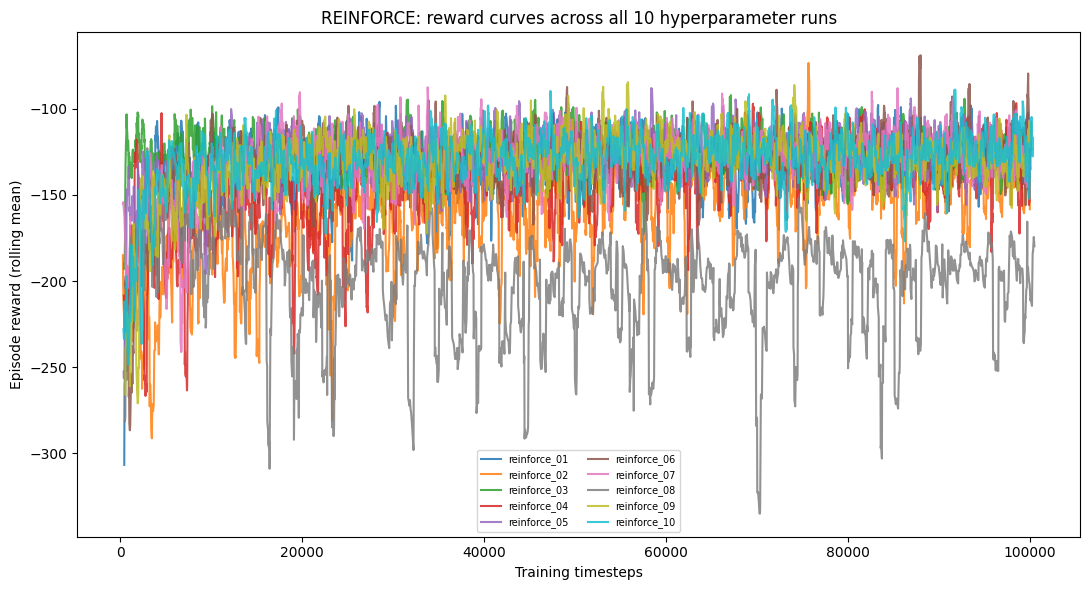

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))
for run in all_runs:
    plt.plot(run["timesteps"], run["smoothed_reward"], label=run["run_id"], alpha=0.85)
plt.xlabel("Training timesteps")
plt.ylabel("Episode reward (rolling mean)")
plt.title(f"REINFORCE: reward curves across all 10 hyperparameter runs")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/all_runs_reward_curves.png", dpi=150)
plt.show()

### Policy entropy curve
Pay special attention to `reinforce_07` (no baseline) — expect its entropy/reward curves to be visibly noisier than `reinforce_01`.

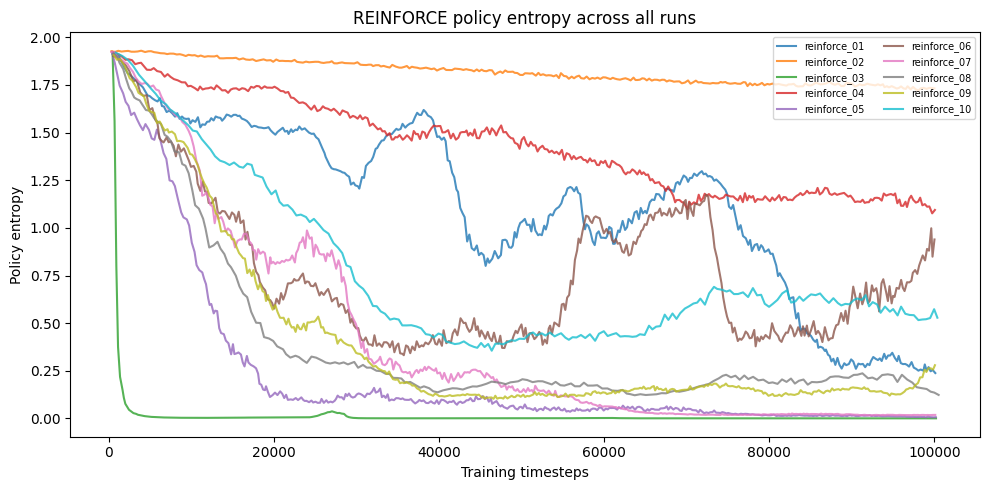

In [15]:
plt.figure(figsize=(10, 5))
for run in all_runs:
    if run["entropies"]:
        plt.plot(run["entropy_steps"], run["entropies"], label=run["run_id"], alpha=0.8)
plt.xlabel("Training timesteps")
plt.ylabel("Policy entropy")
plt.title("REINFORCE policy entropy across all runs")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/reinforce_entropy_curves.png", dpi=150)
plt.show()

## 9. Identify best run, evaluate thoroughly, and save as the official 'best model'

In [16]:
best_run_id = results_df.iloc[0]["run_id"]
print("Best run:", best_run_id)
best_model = policies[best_run_id]

def predict_fn(obs):
    with torch.no_grad():
        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        logits = best_model(obs_t)
        return int(torch.argmax(logits, dim=-1).item())

metrics = evaluate_agent(predict_fn)
print(metrics)

import json
with open(f"{RESULTS_DIR}/best_model_metrics.json", "w") as f:
    json.dump({"best_run_id": str(best_run_id), **metrics}, f, indent=2)

Best run: reinforce_02
{'success_rate': np.float64(0.0), 'avg_reward': -119.5, 'reward_std': 32.44944786381837, 'avg_steps': 23.0, 'avg_battery_left': 0.0, 'avg_hazard_violations': 3.7, 'avg_path_efficiency': 1.529096245765686}


In [17]:
def evaluate_scenario(predict_fn, n=15, low_battery=False, dense_hazards=False):
    env = MedicalDroneEnv()
    successes = []
    for seed in range(5000, 5000 + n):
        obs, info = env.reset(seed=seed)
        if low_battery:
            env.battery = 20.0
        if dense_hazards:
            mid = (env.hospital + env.clinic) / 2
            for i in range(len(env.no_fly_zones)):
                env.no_fly_zones[i] = mid + np.random.default_rng(seed).uniform(-2, 2, size=2)
        done = False
        success = False
        while not done:
            action = predict_fn(obs)
            obs, reward, term, trunc, info = env.step(action)
            if info["event"] == "Delivery successful":
                success = True
            done = term or trunc
        successes.append(success)
    env.close()
    return 100.0 * np.mean(successes)

scenario_results = {
    "low_battery": evaluate_scenario(predict_fn, low_battery=True),
    "dense_hazards": evaluate_scenario(predict_fn, dense_hazards=True),
    "standard": evaluate_scenario(predict_fn),
}
print(scenario_results)

with open(f"{RESULTS_DIR}/scenario_results.json", "w") as f:
    json.dump(scenario_results, f, indent=2)

{'low_battery': np.float64(0.0), 'dense_hazards': np.float64(0.0), 'standard': np.float64(0.0)}


## 10. Record a rollout video of the best agent (headless render, saved to Drive)

In [18]:
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"
os.environ["SDL_AUDIODRIVER"] = "dummy"
import imageio

env = MedicalDroneEnv(render_mode="rgb_array")
obs, info = env.reset(seed=2024)
frames = []
done = False
while not done:
    frame = env.render()
    if frame is not None:
        frames.append(frame)
    action = predict_fn(obs)
    obs, reward, term, trunc, info = env.step(action)
    done = term or trunc
frame = env.render()
if frame is not None:
    frames.append(frame)
env.close()

video_path = f"{VIDEOS_DIR}/reinforce_best_agent_rollout.mp4"
imageio.mimsave(video_path, frames, fps=30)
print("Saved rollout video to", video_path)

Saved rollout video to /content/drive/MyDrive/student_name_rl_summative/assets/videos/reinforce_best_agent_rollout.mp4


## 11. Discussion — what to look for in REINFORCE

- `reinforce_07` (no baseline) vs `reinforce_01` (baseline) is the key comparison in this notebook — the
  variance-reduction effect of a baseline is one of the most well-established results in policy-gradient
  methods, and this ablation should reproduce it directly on this environment.
- `reinforce_03` (lr=1e-2) is expected to be unstable; if the reward curve degrades over training rather than
  improving, that's worth discussing as evidence of REINFORCE's sensitivity to learning rate absent any
  trust-region safeguard (unlike PPO).
- `reinforce_10` (20 episodes/update) trades wall-clock time per update for a lower-variance gradient estimate
  — compare its reward-curve smoothness against `reinforce_01` (10 episodes/update).
- Overall, expect REINFORCE to need more total timesteps than PPO/A2C to reach a comparable success rate,
  since it has no bootstrapped value function and throws away each episode's trajectory after one update.